In [151]:
#Imports
import sys,os
os.environ['MKL_NUM_THREADS'] = '4' # set number of MKL threads to run in parallel
from quspin.operators import hamiltonian,quantum_operator
from quspin.basis import spin_basis_1d
from numpy.random import uniform,seed
from joblib import delayed,Parallel

from itertools import combinations
from functools import partial
import numpy as np
import gc
import pickle
from time import time
from quspin.tools.measurements import diag_ensemble
from quspin.tools.evolution import ED_state_vs_time
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, show, figure, xlabel, ylabel, xscale, yscale, legend, loglog,title,show,imshow,colorbar,legend,scatter
from numpy import pi, exp, log, sin , cos, tan, log, array
import quspin
timestamp = time()
from scipy.optimize import minimize_scalar

# dat and alphasearch already defined



In [152]:

def commute(A,B):
    return A@B-B@A

In [ ]:
###### Model parameters
#Length of chain
L = 2
#X field
J1 = 1 #NN term 
J2 = 0
h0 = 1
###Using Quantum_Operator to build hamitlonian 
basis = spin_basis_1d(L, pauli = -1)
#NN Sigma x term (Periodic Boundary Conditions)
NN_sigma_x = [ [-J1, i, (i+1)%L] for i in range(L)]
NNN_sigma_x = [ [-J2, i, (i+1)%L] for i in range(L)]

#site coupling lists
sigma_z = [ [-1, i] for i in range(L)]
#Define the static H (that doesn't change)
static_H = [ ["xx", NN_sigma_x], ["xx",NNN_sigma_x] ] 
#The z field is the quench
Quenching_H = [["z", sigma_z]]
#Define operator dictionary
operator_dict = dict(H0= static_H, Quench = Quenching_H)
#Build Hamiltonian
H = quantum_operator(operator_dict, basis=basis, check_herm= False, check_symm = False)
#Define Parameters
params_dict = dict( H0=1, Quench=h0)
#Build H0
H1 = H.tohamiltonian(params_dict)
#Find eigenvalues
E1,V1 = np.linalg.eigh(H1.todense())
#Convert matrix to array
V = np.array(V1)
H = array(H1.todense())
E = E1

In [129]:
single_site = [ [-1, i] for i in range(L)]
z_single_site = [["z", single_site]]
operator_dict=dict(S=z_single_site)
partialH= quantum_operator(operator_dict,basis=basis,check_symm=False,check_herm=False)
partialH = array(partialH.todense())



In [130]:
xysites = [ [1, i,(i+1)%L] for i in range(L)]
xysites_op = [ ["yz",xysites], ["zy",xysites]]
operator_dict = dict(S=xysites_op)
xy = quantum_operator(operator_dict,basis=basis,check_symm=False,check_herm=False)
xy = array(xy.todense())


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_56658/14405764.py:2: RuntimeWarning: divide by zero encountered in matmul
  return A@B-B@A
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_56658/14405764.py:2: RuntimeWarning: overflow encountered in matmul
  return A@B-B@A
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_56658/14405764.py:2: RuntimeWarning: invalid value encountered in matmul
  return A@B-B@A
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_56658/3314536550.py:1: RuntimeWarning: divide by zero encountered in matmul
  imshow(np.abs(V.T@commute(1j*commute(xy/2, H) - partialH,H)@V))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_56658/3314536550.py:1: RuntimeWarning: overflow encountered in matmul
  imshow(np.abs(V.T@commute(1j*commute(xy/2, H) - partialH,H)@V))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_56658/3314536550.py:1: RuntimeWarning: invalid value encountered in matmul
  imshow(np.abs(V.T@commute

(0.0, 10.0)

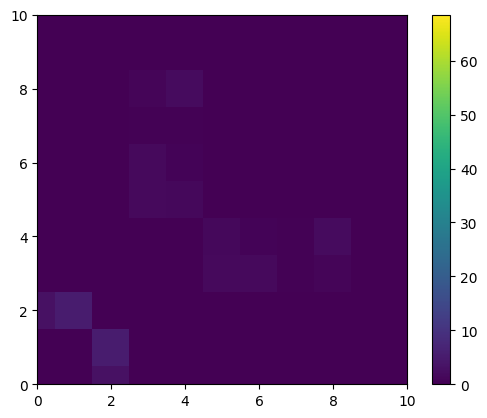

In [133]:
imshow(np.abs(V.T@commute(1j*commute(xy/2, H) - partialH,H)@V))
colorbar()
plt.xlim(0,10)
plt.ylim(0,10)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_56658/14405764.py:2: RuntimeWarning: divide by zero encountered in matmul
  return A@B-B@A
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_56658/14405764.py:2: RuntimeWarning: overflow encountered in matmul
  return A@B-B@A
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_56658/14405764.py:2: RuntimeWarning: invalid value encountered in matmul
  return A@B-B@A
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_56658/4031147581.py:6: RuntimeWarning: divide by zero encountered in matmul
  R2e = V.T.conj() @ R2 @ V
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_56658/4031147581.py:6: RuntimeWarning: overflow encountered in matmul
  R2e = V.T.conj() @ R2 @ V
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_56658/4031147581.py:6: RuntimeWarning: invalid value encountered in matmul
  R2e = V.T.conj() @ R2 @ V


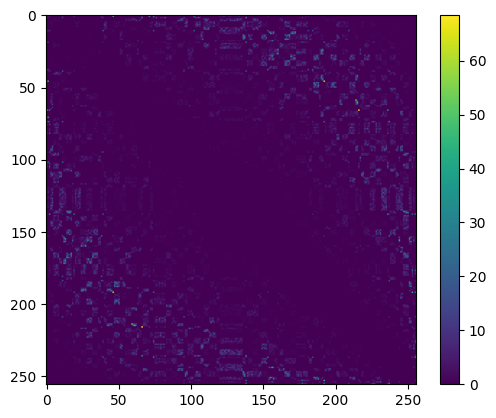

In [132]:
A = xy/2
R = 1j*commute(A, H) - partialH
R2 = commute(R, H)

E, V = np.linalg.eigh(H)
R2e = V.T.conj() @ R2 @ V

imshow(np.abs(R2e))
colorbar()


In [126]:
# exact AGP from definition
A_exact = np.zeros_like(H, dtype=complex)

for m in range(len(E)):
    for n in range(len(E)):
        if m != n and abs(E[m]-E[n]) > 1e-12:
            A_exact[m,n] = 1j * (V[:,m].conj() @ partialH @ V[:,n]) / (E[n]-E[m])

A_exact =A_exact 


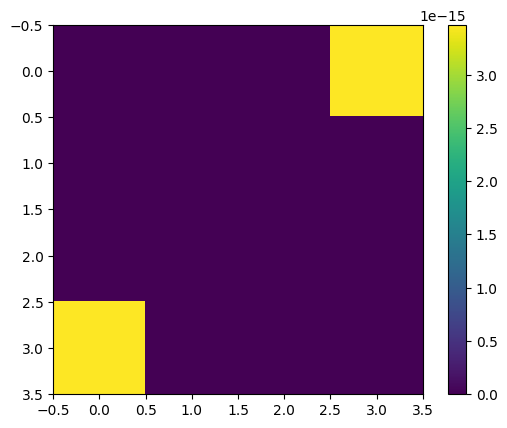

In [127]:
imshow(np.abs(commute(1j*commute(A_exact, H) - partialH,H)))
colorbar()

In [150]:
x=np.array( [ [0 , 1], [0, 0]])
y=np.array( [ [1 , 0], [0, -1]])

print(y)
print(x)
x@y-y@x

[[ 1  0]
 [ 0 -1]]
[[0 1]
 [0 0]]


array([[ 0, -2],
       [ 0,  0]])